# Simple Chatbot with Langgraph
This notebook is my exploration of the [Build a basic chatbot](https://langchain-ai.github.io/langgraph/tutorials/get-started/1-build-basic-chatbot/) tutorial by Langgraph. It is an introduction to the Langgraph framework.

## Required packages
* `langgraph`
* `langsmith`

In [33]:
from typing import Annotated
from typing_extensions import TypedDict

from IPython.display import Image, display, Markdown
from langchain.chat_models import init_chat_model
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

In [21]:
# Load Anthropic API key.
from dotenv import load_dotenv
load_dotenv("../../secrets.env")

True

## Graph
In Langgraph, *an agent is defined as a graph*. The nodes of the graph refer to specific LLMs or functions/tools that can be called. The edges denote how the data in the graph flows i.e. how to transition between nodes.

A Langgraph graph is referred to as a `StateGraph` which is initialised as follows:

In [4]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)

`Annotated` is a new kind of type hint introduced in Python 3.9. It decorates the existing type hint with context-specific metadata. In the `State` class above, `messages` is a list and its metadata references the `add_messages()` function in Langgraph. When the `State` class is passed to `StateGraph`, the latter uses the `get_type_hints()` function from the `typing` module to extract the type and metadata for the `messages` attribute (see methods `_add_schema()` and `_get_channel()` in `libs/langgraph/langgraph/graph/state.py`). Langgraph then understands that when updating the `messages` attribute, instead of a simple list replacement, the new messages should be appended to the existing list. The definition of `add_messages()` can be found in `libs/langgraph/langgraph/graph/message.py`.

The `State` class defines the graph's schema and reducer functions to handle updates to the graph's state. In this class, the graph's schema consists of a single key: `messages`. The `add_messages()` function, as described above, appends new messages to the existing list of messages instead of overwriting them.

`StateGraph` also takes care of passing the `State` as input to each of the nodes in the graph and also updates the state with the output from the node.

## Node
In a Langgraph agent, a *node* typically carries out work and hence is often a regular Python function. First, we initialise an object of the `ChatAnthropic` class that allows us to send messages to Anthropic's Claude API and get a response from the LLM. We specify the LLM to be the latest version of Claude Sonnet 4.0.

In [23]:
llm = init_chat_model("anthropic:claude-sonnet-4-0")

Next, we define a chatbot function that gets the state of the graph (i.e. agent) as an input. It takes the messages from the state, which should contain the entire conversation history along with the latest question, and passes them to the `ChatAnthropic` object to get a response from the LLM. It is essential that the data returned by the chatbot function matches the schema of the graph. Since the graph defined earlier contains a `messages` key, the function returns a dictionary with this key and the response of the LLM.

Finally, we fit the chatbot function in the graph. We define the function as a node with a unique name (`"chatbot"`) and the `chatbot` function we defined previously.

In [25]:
# Define chatbot function to interact with the language model
def chatbot(state: State):
    return {"messages": [llm.invoke(state["messages"])]}

# Add the chatbot to the graph.
graph_builder.add_node("chatbot", chatbot)

## Entry and Exit
For each Langgraph agent/graph, we should specify the entry (`START`) and exit (`END`) nodes. These are special nodes which inform where the graph's work should begin and end. Below, we define a simple graph that executes the `chatbot()` function and exits.

In [26]:
graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("chatbot", END)

## Compile and visualise
Before running a graph, we need to compile it. Once compiled, we can visualise the graph to understand the data and control flows.

In [27]:
graph = graph_builder.compile()

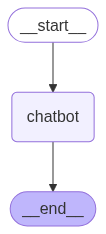

In [29]:
display(Image(graph.get_graph().draw_mermaid_png()))

## Running the agent
We can now run the agent and get answers to our questions. To achieve this, we capture the question using the `input()` function and pass it to the graph using the `stream()` method which the schema it expects i.e. a dictionary with the `messages` key. The `role` is set to `"user"` in order to identify that the question comes from a human. The graph then passes the question to the LLM and its output is captured in a dictionary called `event`. We iterate over the values of this dictionary and display the answer by the LLM as Markdown text.

We can ask multiple questions to the chatbot and the loop only ends when we enter one of `"exit"` or `"quit"`. It is important to remember though that with call of the graph, its state is refreshed and the `messages` list is empty. Hence, we cannot yet have a multi-turn conversation with a LLM which requires persistence of previous conversations.

In [42]:
def stream_graph_updates(user_input: str):
    for event in graph.stream({"messages": [{"role": "user", "content": user_input}]}):
        for value in event.values():
            display(Markdown("**Assistant:**\n" + value["messages"][-1].content))

while True:
    user_input = input("User: ")
    if user_input.lower() in ["exit", "quit"]:
        break
    display(Markdown(f"**Question**:\n{user_input}\n"))
    stream_graph_updates(user_input)

**Question**:
Introduce the country India in 5 sentences.


**Assistant:**
India is a vast South Asian nation with over 1.4 billion people, making it the world's most populous country. It is renowned for its incredible diversity, encompassing hundreds of languages, multiple religions, and a rich tapestry of cultures that vary dramatically from region to region. The country boasts a civilization spanning thousands of years, home to ancient monuments like the Taj Mahal and philosophical traditions that have influenced the world. Modern India is a major global economy and the world's largest democracy, with thriving technology, film, and manufacturing industries. From the snow-capped Himalayas in the north to tropical beaches in the south, India offers an extraordinary range of landscapes, cuisines, and experiences.

`graph.stream()` contains an argument called `stream_mode` which can be used to debug the graph by checking the content of `messages`. By setting this argument to `"values"`, whenever the `messages` list is updated, the updated list is returned. It allows us to debug the data in the graph at every step of execution.

In [ ]:
for event in graph.stream(
    {"messages": [
        {"role": "user", 
        "content": "Introduce the country India in 5 sentences"
        }]}, 
    stream_mode="values"
):
    for value in event.values():
        print("\n" + "="*40 + "\nState Update:\n" + "="*40)
        for i, message in enumerate(value, 1):
            print(f"\n  Message {i}:")
            print("  " + "-"*30)
            if hasattr(message, "content"):
                print(f"    Content: {getattr(message, 'content', 'N/A')}")
            # Print additional keys if present
            if hasattr(message, "additional_kwargs") and getattr(message, "additional_kwargs"):
                print(f"    Additional kwargs: {getattr(message, 'additional_kwargs')}")
            if hasattr(message, "response_metadata") and getattr(message, "response_metadata", None):
                print(f"    Response metadata: {getattr(message, 'response_metadata')}")
            if hasattr(message, "id"):
                print(f"    ID: {getattr(message, 'id')}")
            print("\n" + "="*40 + "\n")


State Update:

  Message 1:
  ------------------------------
    Content: Introduce the country India in 5 sentences
    ID: c1c76a8e-5be0-4a61-ab72-fc272fa71875



State Update:

  Message 1:
  ------------------------------
    Content: Introduce the country India in 5 sentences
    ID: c1c76a8e-5be0-4a61-ab72-fc272fa71875



  Message 2:
  ------------------------------
    Content: India is a vast South Asian country with over 1.4 billion people, making it the world's most populous nation. Located on a peninsula bordered by the Arabian Sea and Bay of Bengal, India shares land boundaries with Pakistan, China, Nepal, Bhutan, Bangladesh, and Myanmar. The country is renowned for its incredible diversity, with hundreds of languages spoken, multiple major religions practiced, and a rich tapestry of cultures and traditions spanning thousands of years. India operates as the world's largest democracy, with a federal parliamentary system and 28 states, while its economy has emerged as one o